# Notebook to Explore The data : see shapes, label counts and other exploratory things

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
submission_df = pd.read_csv('../data/example_submission.csv', header=None)


In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Submission shape:", submission_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train shape: (28709, 2)
Test shape: (7178, 1)
Submission shape: (3589, 1)

Train columns: ['emotion', 'pixels']
Test columns: ['pixels']


In [5]:
print(train_df['emotion'].unique())

[0 2 4 6 3 5 1]


In [6]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral",
}

In [7]:
label_counts = train_df["emotion"].value_counts().sort_index()

for label_id, count in label_counts.items():
    print(label_id, emotion_labels[label_id], count)

0 Angry 3995
1 Disgust 436
2 Fear 4097
3 Happy 7215
4 Sad 4830
5 Surprise 3171
6 Neutral 4965


# Check The Distribution of expressions

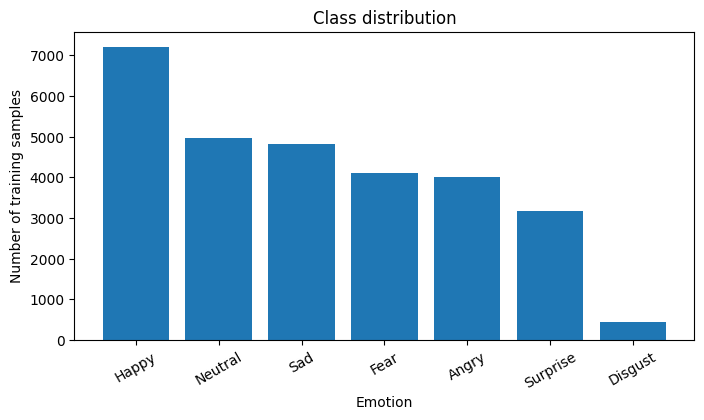

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(
    [emotion_labels[i] for i in label_counts.index],
    label_counts.values
)

plt.title("Class distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of training samples")
plt.xticks(rotation=30)
plt.show()

# Visualize first Image Train set

Label: 0 Angry
Pixel count: 2304
Image shape: (48, 48)


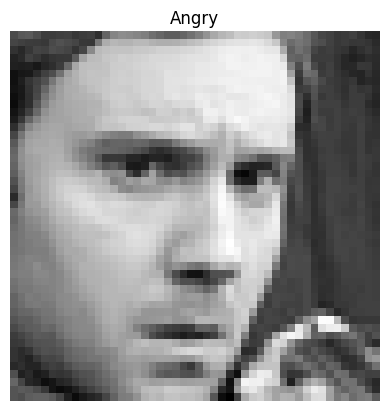

In [13]:
row = train_df.iloc[0]

label = row["emotion"]
pixels = row["pixels"]

pixel_values = np.array(pixels.split(), dtype=np.uint8)
image = pixel_values.reshape(48, 48)

print("Label:", label, emotion_labels[label])
print("Pixel count:", len(pixel_values))
print("Image shape:", image.shape)

plt.imshow(image, cmap="gray")
plt.title(emotion_labels[label])
plt.axis("off")
plt.show()

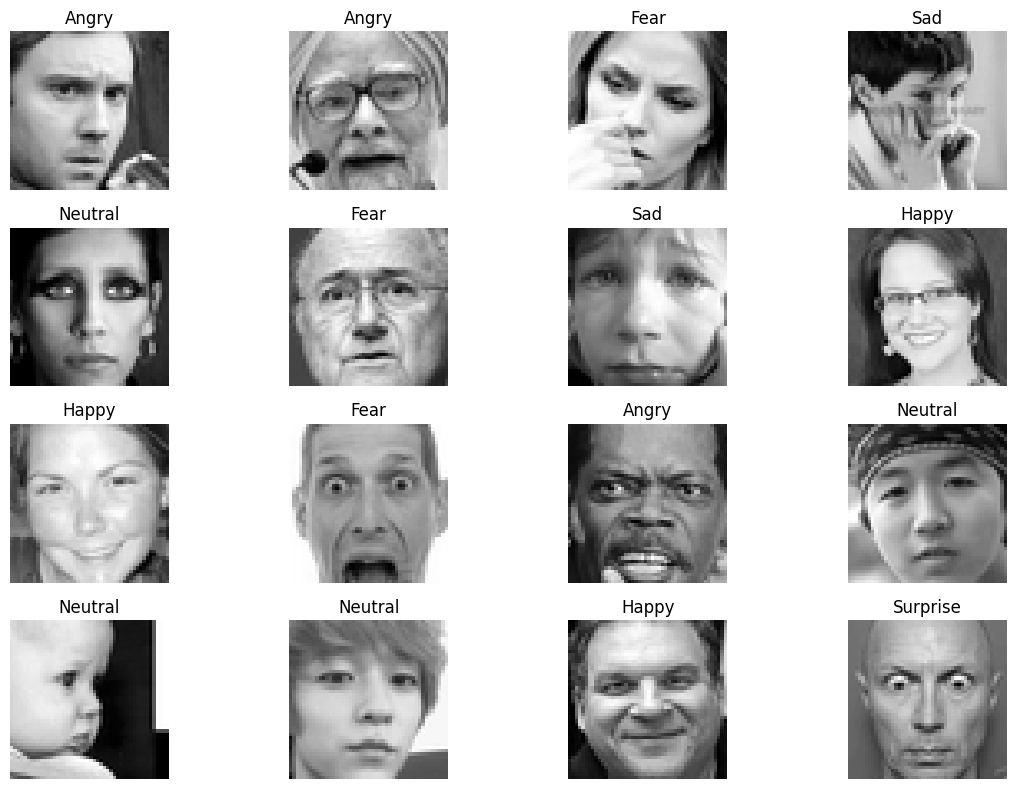

In [16]:
plt.figure(figsize=(12, 8))

for i in range(16):
    row = train_df.iloc[i]
    label = row["emotion"]
    image = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48,48)

    plt.subplot(4, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion_labels[label])
    plt.axis("off")

plt.tight_layout()
plt.show()